In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

**## SVD for PCA (Dimensionality Reduction)**

Original data shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']

Explained variance ratio:
  PC1: 92.46%
  PC2: 5.31%
  PC3: 1.71%
  PC4: 0.52%


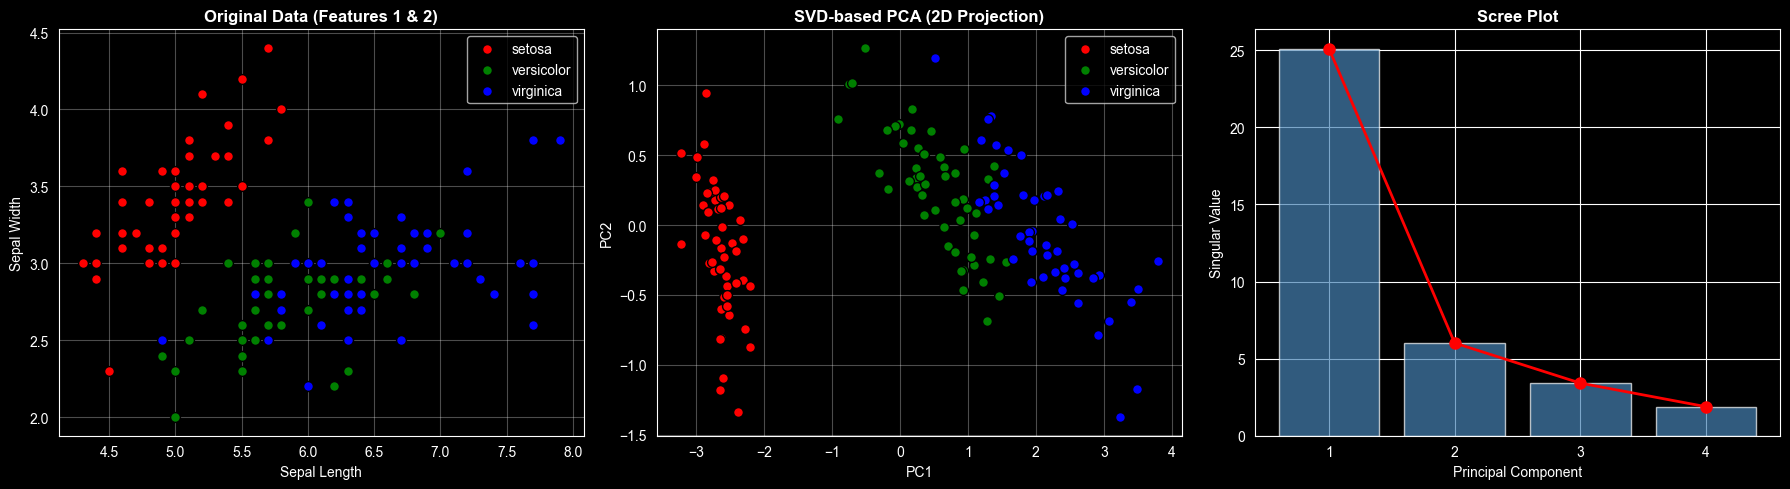


Projection shape: (150, 2)
Total variance explained by PC1+PC2: 97.77%


In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

print(f"Original data shape: {X.shape}")
print(f"Classes: {target_names}")

# Center the data (subtract mean)
X_centered = X - np.mean(X, axis=0)

# Perform SVD on centered data
U_iris, s_iris, Vt_iris = np.linalg.svd(X_centered, full_matrices=False)

# Project onto top 2 principal components
k = 2
X_pca_svd = U_iris[:, :k] * s_iris[:k]  # Equivalent to X_centered @ Vt_iris[:k, :].T

print(f"\nExplained variance ratio:")
explained_var = (s_iris**2) / np.sum(s_iris**2)
for i in range(len(s_iris)):
    print(f"  PC{i+1}: {explained_var[i]*100:.2f}%")

# Compare with sklearn PCA
from sklearn.decomposition import PCA
pca_sklearn = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_centered)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original data (first 2 features)
ax = axes[0]
colors = ['red', 'green', 'blue']
for i, target_name in enumerate(target_names):
    ax.scatter(X[y==i, 0], X[y==i, 1], c=colors[i], label=target_name, edgecolors='k', s=50)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_title('Original Data (Features 1 & 2)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# SVD-based PCA
ax = axes[1]
for i, target_name in enumerate(target_names):
    ax.scatter(X_pca_svd[y==i, 0], X_pca_svd[y==i, 1], c=colors[i], label=target_name, edgecolors='k', s=50)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('SVD-based PCA (2D Projection)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Scree plot
ax = axes[2]
ax.bar(range(1, len(s_iris)+1), s_iris, color='steelblue', alpha=0.7)
ax.plot(range(1, len(s_iris)+1), s_iris, 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Singular Value')
ax.set_title('Scree Plot', fontweight='bold')
ax.set_xticks(range(1, len(s_iris)+1))

plt.tight_layout()
plt.show()

print(f"\nProjection shape: {X_pca_svd.shape}")
print(f"Total variance explained by PC1+PC2: {np.sum(explained_var[:2])*100:.2f}%")